# Social Indicators

## Correlation analysis

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [43]:
df = pd.read_csv("data/data.csv")

df

,Country Name,Code,Year,Ed Gov Expenditure,Ed Post Secondary,Ec GNI per capita,Ec Gini Index,Birth Rate,Fem Labor Ratio,Fem Parliament Sits,Life Expectancy,Rule of Law
0,Aruba,ABW,2000,21.807711,NaN,20060.0,NaN,14.260,78.202,NaN,72.9393,NaN
1,Aruba,ABW,2001,21.323179,NaN,20340.0,NaN,13.813,NaN,NaN,73.0437,NaN
2,Aruba,ABW,2002,19.757151,NaN,19220.0,NaN,13.337,NaN,NaN,73.1355,NaN
3,Aruba,ABW,2003,NaN,NaN,21020.0,NaN,13.358,NaN,NaN,73.2362,NaN
4,Aruba,ABW,2004,14.902910,NaN,23610.0,NaN,12.540,NaN,NaN,73.2230,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
9819,Zimbabwe,ZWE,2022,NaN,NaN,2580.0,NaN,30.882,83.313,30.566,62.3601,0.391414
9820,Zimbabwe,ZWE,2023,10.688962,NaN,2550.0,NaN,30.410,83.521,30.682,62.7748,0.396527
9821,Zimbabwe,ZWE,2023,10.688962,NaN,2550.0,NaN,30.410,83.522,30.682,62.7748,0.396527
9822,Zimbabwe,ZWE,2024,16.320335,NaN,2400.0,NaN,29.891,83.535,28.090,NaN,0.396732


<Axes: >

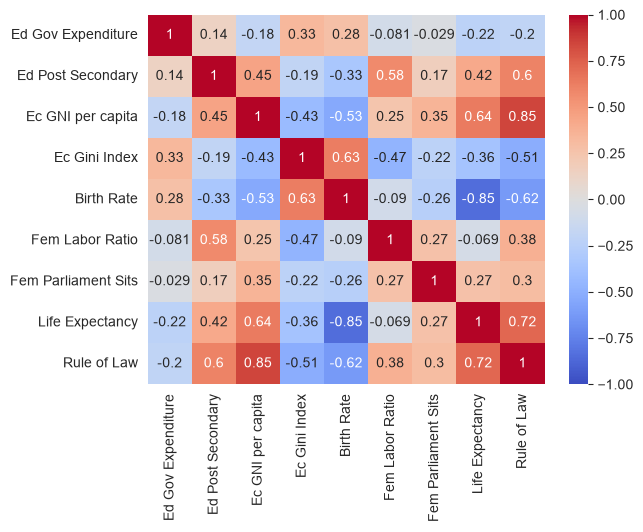

In [44]:
sns.heatmap(
    data = df.drop(columns=['Country Name', 'Code', 'Year']).corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    cmap='coolwarm',
)

Does Ed gov expenditure has impact on something or it just conclusion of high birth rate in some countries.

Gini index - statistical dispersion of income, wealth, and consumption inequality (less - better)

<Axes: xlabel='Fem Labor Ratio', ylabel='Ec Gini Index'>

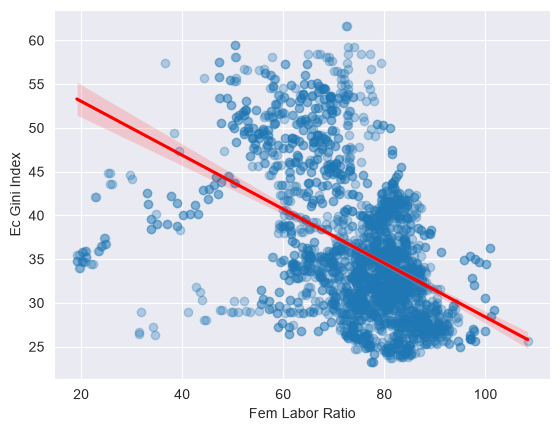

In [45]:
sns.regplot(
    data=df,
    x='Fem Labor Ratio',
    y='Ec Gini Index',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

Education government expenditure shows a low correlation with almost all indicators except of Gini index and Birth rate. It seems that this is more of a consequence than a cause.

In the opposite, Post secondary rate has a strong correlation with most metrics that shows positive impact on other spheres of life.

Some people might note, that Birth rate decreasing is bad, but a higher Birth rate, in general, correlate with most other metrics in a bad way.

Also, Female parliament sits has not such strong, but often positive relations with other aspects of society.

Rule of law has a remarkably huge impact positive impact on each sphere.

In [46]:
x = 'Fem Labor Ratio'
y = 'Ec Gini Index'


def get_paired_diffs(x, y):
    dfxy = df[['Code', 'Year', x, y]]

    differences = []
    for country in dfxy['Code'].unique():
        c_data = dfxy[dfxy['Code'] == country]
        low = c_data[c_data[x] < c_data[x].median()]
        high = c_data[c_data[x] >= c_data[x].median()]
        if len(low) > 0:
            diff = high[y].mean() - low[y].mean()
            if pd.notnull(diff):
                differences.append(diff)
    return differences

def bootstrap_paired_diffs(diffs, n=10000):
    bootstrap_means = []
    size = len(diffs)
    for _ in range(n):
        resampled_differences = np.random.choice(diffs, size=size, replace=True)
        bootstrap_means.append(np.mean(resampled_differences))
    return bootstrap_means

diffs = get_paired_diffs(x, y)
means = bootstrap_paired_diffs(diffs)
lower_ci = np.percentile(means, 2.5)
upper_ci = np.percentile(means, 97.5)
print(lower_ci, upper_ci)

-1.3367297755210703 -0.0627327944514784


In [47]:
t_stat, p_value = stats.ttest_1samp(diffs, 0)
print(p_value)

0.039184108086114555


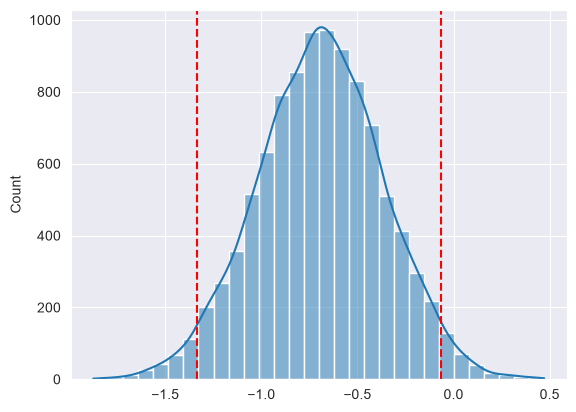

In [48]:
ax = sns.histplot(
    x=means,
    bins=30,
    kde=True
)
ax.axvline(
    lower_ci,
    color='red',
    linestyle='--'
)
ax.axvline(
    upper_ci,
    color='red',
    linestyle='--'
)
plt.show(ax)

In [59]:
columns = df.drop(columns=['Country Name', 'Code', 'Year']).columns

x = 'Fem Labor Ratio'
y = 'Ec Gini Index'

def check_stat_sign(x, y):
    diffs = get_paired_diffs(x, y)
    means = bootstrap_paired_diffs(diffs)
    lower_ci = np.percentile(means, 2.5)
    upper_ci = np.percentile(means, 97.5)
    return lower_ci * upper_ci > 0

print(check_stat_sign(x, y))

arr_0 = []
for i in columns:
    arr_1 = []
    for j in columns:
        if i == j:
            arr_1.append(0)
            continue
        arr_1.append(check_stat_sign(i, j))
    arr_0.append(arr_1)

checks = pd.DataFrame(
    arr_0,
    index=columns,
    columns=columns
)

checks

True


,Ed Gov Expenditure,Ed Post Secondary,Ec GNI per capita,Ec Gini Index,Birth Rate,Fem Labor Ratio,Fem Parliament Sits,Life Expectancy,Rule of Law
Ed Gov Expenditure,0,True,False,False,True,False,True,False,False
Ed Post Secondary,True,0,True,False,True,True,True,True,False
Ec GNI per capita,False,True,0,True,True,True,True,True,False
Ec Gini Index,False,False,False,0,True,False,True,True,False
Birth Rate,True,True,True,True,0,True,True,True,True
Fem Labor Ratio,False,True,True,True,True,0,True,True,False
Fem Parliament Sits,False,True,True,True,True,True,0,True,False
Life Expectancy,False,True,True,True,True,True,True,0,True
Rule of Law,True,False,True,False,True,False,True,False,0
